# Using Jupyter Notebooks
:label:`sec_jupyter`


This section describes how to edit and run the code
in each section of this book
using the Jupyter Notebook. Make sure you have
installed Jupyter and downloaded the
code as described in
:ref:`chap_installation`.
If you want to know more about Jupyter see the excellent tutorial in
their [documentation](https://jupyter.readthedocs.io/en/latest/).


## Editing and Running the Code Locally

Suppose that the local path of the book's code is `xx/yy/d2l-en/`. Use the shell to change the directory to this path (`cd xx/yy/d2l-en`) and run the command `jupyter notebook`. If your browser does not do this automatically, open http://localhost:8888 and you will see the interface of Jupyter and all the folders containing the code of the book, as shown in :numref:`fig_jupyter00`.

![The folders containing the code of this book.](https://github.com/d2l-ai/d2l-en-colab/blob/master/img/jupyter00.png?raw=1)
:width:`600px`
:label:`fig_jupyter00`


You can access the notebook files by clicking on the folder displayed on the webpage.
They usually have the suffix ".ipynb".
For the sake of brevity, we create a temporary "test.ipynb" file.
The content displayed after you click it is
shown in :numref:`fig_jupyter01`.
This notebook includes a markdown cell and a code cell. The content in the markdown cell includes "This Is a Title" and "This is text.".
The code cell contains two lines of Python code.

![Markdown and code cells in the "text.ipynb" file.](https://github.com/d2l-ai/d2l-en-colab/blob/master/img/jupyter01.png?raw=1)
:width:`600px`
:label:`fig_jupyter01`


Double click on the markdown cell to enter edit mode.
Add a new text string "Hello world." at the end of the cell, as shown in :numref:`fig_jupyter02`.

![Edit the markdown cell.](https://github.com/d2l-ai/d2l-en-colab/blob/master/img/jupyter02.png?raw=1)
:width:`600px`
:label:`fig_jupyter02`


As demonstrated in :numref:`fig_jupyter03`,
click "Cell" $\rightarrow$ "Run Cells" in the menu bar to run the edited cell.

![Run the cell.](https://github.com/d2l-ai/d2l-en-colab/blob/master/img/jupyter03.png?raw=1)
:width:`600px`
:label:`fig_jupyter03`

After running, the markdown cell is shown in :numref:`fig_jupyter04`.

![The markdown cell after running.](https://github.com/d2l-ai/d2l-en-colab/blob/master/img/jupyter04.png?raw=1)
:width:`600px`
:label:`fig_jupyter04`


Next, click on the code cell. Multiply the elements by 2 after the last line of code, as shown in :numref:`fig_jupyter05`.

![Edit the code cell.](https://github.com/d2l-ai/d2l-en-colab/blob/master/img/jupyter05.png?raw=1)
:width:`600px`
:label:`fig_jupyter05`


You can also run the cell with a shortcut ("Ctrl + Enter" by default) and obtain the output result from :numref:`fig_jupyter06`.

![Run the code cell to obtain the output.](https://github.com/d2l-ai/d2l-en-colab/blob/master/img/jupyter06.png?raw=1)
:width:`600px`
:label:`fig_jupyter06`


When a notebook contains more cells, we can click "Kernel" $\rightarrow$ "Restart & Run All" in the menu bar to run all the cells in the entire notebook. By clicking "Help" $\rightarrow$ "Edit Keyboard Shortcuts" in the menu bar, you can edit the shortcuts according to your preferences.

## Advanced Options

Beyond local editing two things are quite important: editing the notebooks in the markdown format and running Jupyter remotely.
The latter matters when we want to run the code on a faster server.
The former matters since Jupyter's native ipynb format stores a lot of auxiliary data that is
irrelevant to the content,
mostly related to how and where the code is run.
This is confusing for Git, making
reviewing contributions very difficult.
Fortunately there is an alternative---native editing in the markdown format.

### Markdown Files in Jupyter

If you wish to contribute to the content of this book, you need to modify the
source file (md file, not ipynb file) on GitHub.
Using the notedown plugin we
can modify notebooks in the md format directly in Jupyter.


First, install the notedown plugin, run the Jupyter Notebook, and load the plugin:

```
pip install d2l-notedown  # You may need to uninstall the original notedown.
jupyter notebook --NotebookApp.contents_manager_class='notedown.NotedownContentsManager'
```

You may also turn on the notedown plugin by default whenever you run the Jupyter Notebook.
First, generate a Jupyter Notebook configuration file (if it has already been generated, you can skip this step).

```
jupyter notebook --generate-config
```

Then, add the following line to the end of the Jupyter Notebook configuration file (for Linux or macOS, usually in the path `~/.jupyter/jupyter_notebook_config.py`):

```
c.NotebookApp.contents_manager_class = 'notedown.NotedownContentsManager'
```

After that, you only need to run the `jupyter notebook` command to turn on the notedown plugin by default.

### Running Jupyter Notebooks on a Remote Server

Sometimes, you may want to run Jupyter notebooks on a remote server and access it through a browser on your local computer. If Linux or macOS is installed on your local machine (Windows can also support this function through third-party software such as PuTTY), you can use port forwarding:

```
ssh myserver -L 8888:localhost:8888
```

The above string `myserver` is the address of the remote server.
Then we can use http://localhost:8888 to access the remote server `myserver` that runs Jupyter notebooks. We will detail on how to run Jupyter notebooks on AWS instances
later in this appendix.

### Timing

We can use the `ExecuteTime` plugin to time the execution of each code cell in Jupyter notebooks.
Use the following commands to install the plugin:

```
pip install jupyter_contrib_nbextensions
jupyter contrib nbextension install --user
jupyter nbextension enable execute_time/ExecuteTime
```

## Summary

* Using the Jupyter Notebook tool, we can edit, run, and contribute to each section of the book.
* We can run Jupyter notebooks on remote servers using port forwarding.


## Exercises

1. Edit and run the code in this book with the Jupyter Notebook on your local machine.
1. Edit and run the code in this book with the Jupyter Notebook *remotely* via port forwarding.
1. Compare the running time of the operations $\mathbf{A}^\top \mathbf{B}$ and $\mathbf{A} \mathbf{B}$ for two square matrices in $\mathbb{R}^{1024 \times 1024}$. Which one is faster?


[Discussions](https://discuss.d2l.ai/t/421)


In [1]:
!pip install psycopg2-binary sqlalchemy ipython-sql

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 46.0 MB/s eta 0:00:00


In [3]:
from sqlalchemy import create_engine
import pandas as pd
from google.colab import userdata

# Retrieve credentials securely from Colab Secrets
try:
    db_user = userdata.get('DB_USER')
    db_password = userdata.get('DB_PASSWORD')
    db_host = userdata.get('DB_HOST')
    db_port = userdata.get('DB_PORT')
    db_name = userdata.get('DB_NAME')

    # Construct the connection URI securely
    db_uri = f"postgresql://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}"
    engine = create_engine(db_uri)

    # Read data directly into a Pandas DataFrame
    df = pd.read_sql("SELECT * FROM your_table", engine)
    display(df.head())
except Exception as e:
    print(f"Ensure you have added DB_USER, DB_PASSWORD, DB_HOST, DB_PORT, and DB_NAME to Colab Secrets: {e}")

Ensure you have added DB_USER, DB_PASSWORD, DB_HOST, DB_PORT, and DB_NAME to Colab Secrets: Secret DB_USER does not exist.


In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mohankrishnathalla/global-ai-adoption-and-workforce-impact-dataset")

print("Path to dataset files:", path)

100%|██████████| 9.35M/9.35M [00:00<00:00, 33.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/mohankrishnathalla/global-ai-adoption-and-workforce-impact-dataset/versions/1


Loaded dataset: ai_company_adoption.csv with shape (150000, 43)
Available columns: ['response_id', 'company_id', 'survey_year', 'quarter', 'country', 'region', 'industry', 'company_size', 'num_employees', 'annual_revenue_usd_millions', 'company_founding_year', 'company_age', 'company_age_group', 'ai_adoption_rate', 'ai_adoption_stage', 'years_using_ai', 'ai_primary_tool', 'num_ai_tools_used', 'ai_use_case', 'ai_projects_active', 'ai_training_hours', 'ai_budget_percentage', 'ai_maturity_score', 'ai_failure_rate', 'ai_investment_per_employee', 'regulatory_compliance_score', 'data_privacy_level', 'ai_ethics_committee', 'ai_risk_management_score', 'remote_work_percentage', 'employee_satisfaction_score', 'task_automation_rate', 'time_saved_per_week', 'productivity_change_percent', 'jobs_displaced', 'jobs_created', 'reskilled_employees', 'revenue_growth_percent', 'cost_reduction_percent', 'innovation_score', 'customer_satisfaction', 'survey_source', 'data_collection_method']


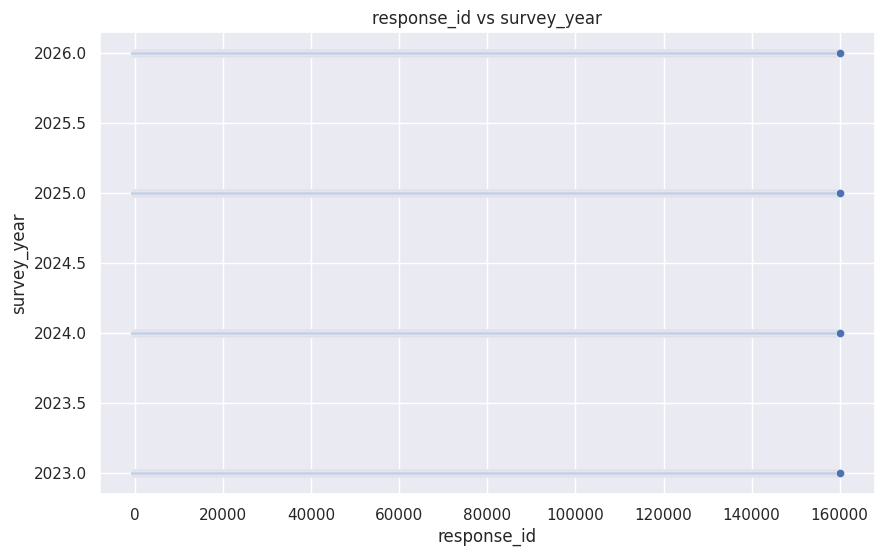

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os

# 1. Use the path from kagglehub to load the actual dataset
dataset_dir = "/root/.cache/kagglehub/datasets/mohankrishnathalla/global-ai-adoption-and-workforce-impact-dataset/versions/1"
csv_files = [f for f in os.listdir(dataset_dir) if f.endswith('.csv')]

if not csv_files:
    print("No CSV files found in the dataset directory!")
else:
    csv_path = os.path.join(dataset_dir, csv_files[0])
    df = pd.read_csv(csv_path)
    print(f"Loaded dataset: {csv_files[0]} with shape {df.shape}")
    print("Available columns:", df.columns.tolist())

    # 2. Set the default Seaborn style
    sns.set_theme()

    # 3. Create a scatter plot using real columns from this dataset
    # Checking typical numeric columns present in this dataset schema
    x_col = 'Automation_Risk' if 'Automation_Risk' in df.columns else df.select_dtypes(include='number').columns[0]
    y_col = 'Impact_on_Jobs' if 'Impact_on_Jobs' in df.columns else df.select_dtypes(include='number').columns[1]

    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x=x_col, y=y_col, alpha=0.7)
    plt.title(f"{x_col} vs {y_col}")

    # 4. Display the plot
    plt.show()

In [ ]:
kaggle kernels pull mohankrishnathalla/global-ai-adoption-trends-eda-insights

In [7]:
pip install kaggle pandas

Created mockup file: 'employee_data.csv'


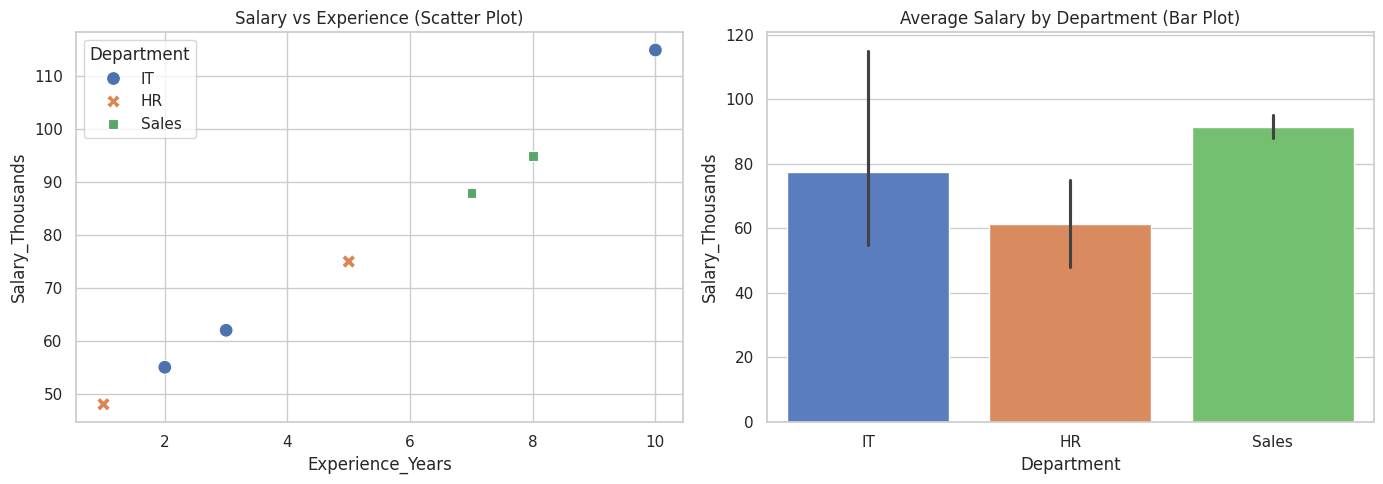

In [10]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

csv_filename = "employee_data.csv"
df_original.to_csv(csv_filename, index=True)
print(f"Created mockup file: '{csv_filename}'")


# 2. Read the CSV file into a Pandas DataFrame
# Reading the actual mockup CSV file we just created above
df = pd.read_csv(csv_filename)


# 3. Initialize the Seaborn theme style
sns.set_theme(style="whitegrid")

# Create a figure to hold multiple subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Scatter plot exploring two numeric columns (Experience vs Salary)
sns.scatterplot(
    data=df,
    x="Experience_Years",
    y="Salary_Thousands",
    hue="Department",  # Colors points by categorical department
    style="Department",  # Changes marker shapes by department
    s=100,  # Size of markers
    ax=axes[0],
)
axes[0].set_title("Salary vs Experience (Scatter Plot)")


# Plot 2: Bar plot calculating the average salary per department
sns.barplot(
    data=df,
    x="Department",
    y="Salary_Thousands",
    hue="Department",  # Colors bars cleanly
    palette="muted",
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Average Salary by Department (Bar Plot)")


# 4. Display the plots on your screen
plt.tight_layout()
plt.show()

# Clean up local file created for this example
if os.path.exists(csv_filename):
    os.remove(csv_filename)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   road_type  100 non-null    object
 1   reason     100 non-null    object
dtypes: object(2)
memory usage: 1.7+ KB
None
          road_type              reason
0  National Highway            Speeding
1     State Highway      Driver Fatigue
2        Local Road  Weather Conditions
3        Expressway            Speeding
4  National Highway             Alcohol


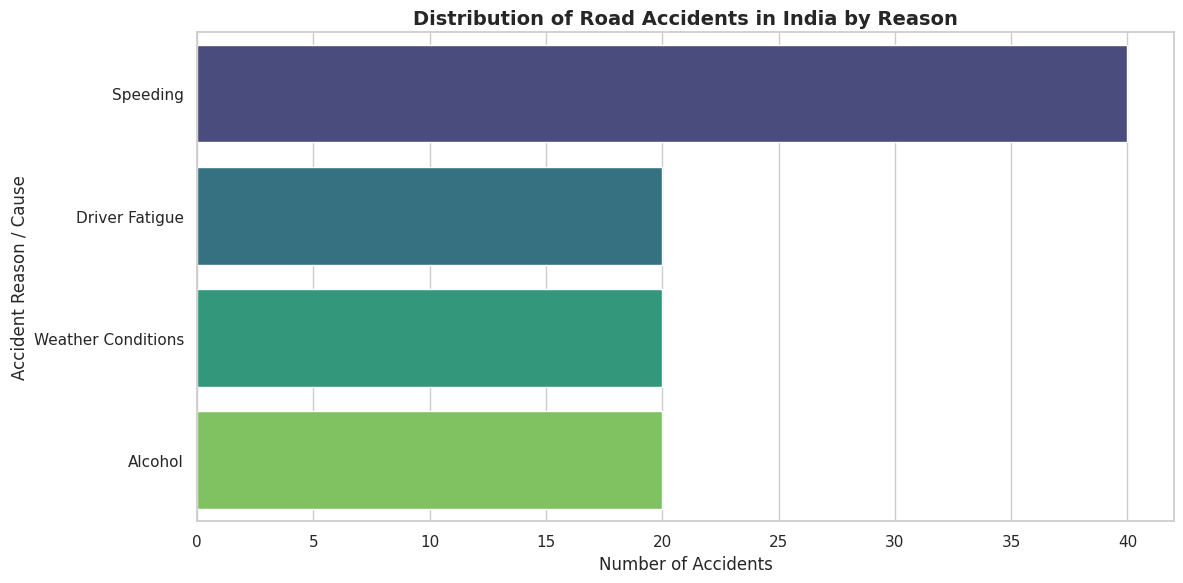

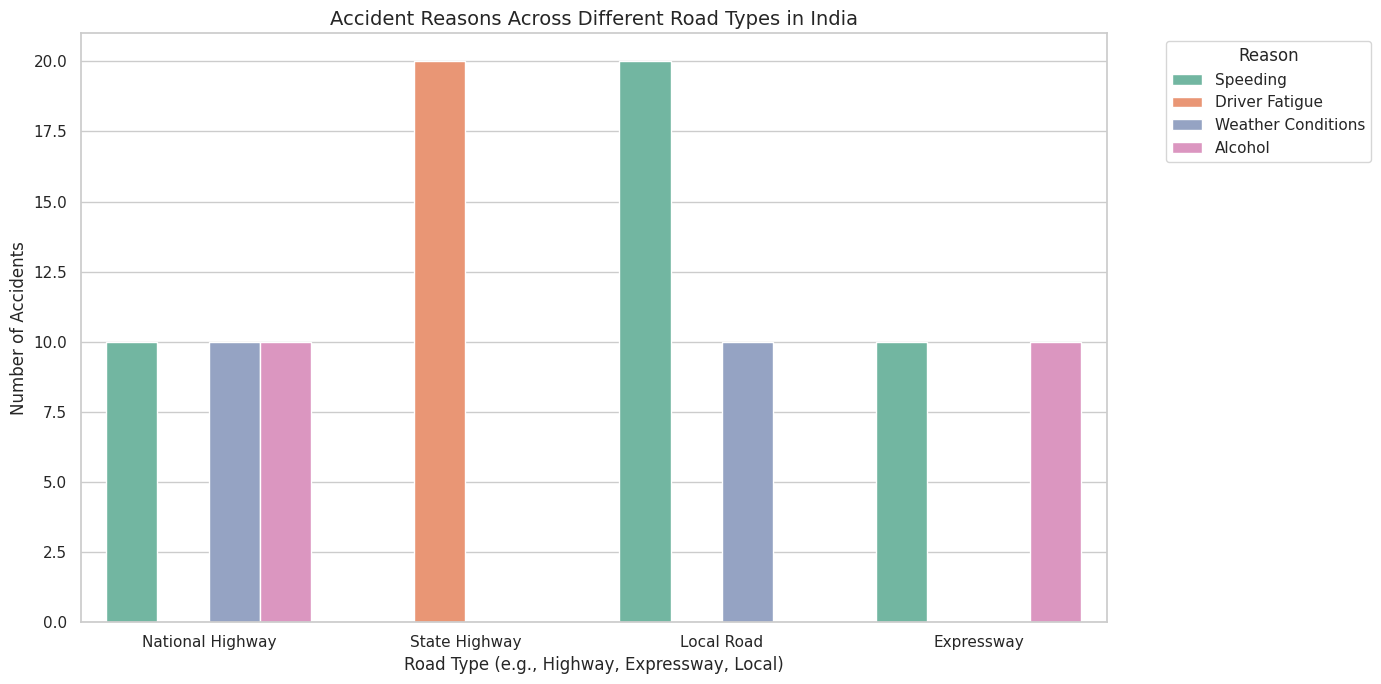

In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os

# Set the visual style for seaborn
sns.set_theme(style="whitegrid")

file_path = "india_road_accidents.csv"

# Generate a mockup dataset if the file does not exist
if not os.path.exists(file_path):
    print(f"'{file_path}' not found. Generating a mockup dataset for demonstration...")
    mock_data = {
        "road_type": ["National Highway", "State Highway", "Local Road", "Expressway", "National Highway", "Local Road", "State Highway", "National Highway", "Expressway", "Local Road"],
        "reason": ["Speeding", "Driver Fatigue", "Weather Conditions", "Speeding", "Alcohol", "Speeding", "Driver Fatigue", "Weather Conditions", "Alcohol", "Speeding"]
    }
    # Multiply the mock data to have a reasonably sized dataset
    mock_data["road_type"] = mock_data["road_type"] * 10
    mock_data["reason"] = mock_data["reason"] * 10
    df_mock = pd.DataFrame(mock_data)
    df_mock.to_csv(file_path, index=False)

# Load the dataset
df = pd.read_csv(file_path)

# Display basic information about the dataset
print("Dataset Info:")
print(df.info())
print(df.head())

# Create a figure for subplots or single plots
plt.figure(figsize=(12, 6))

# Plot count of accidents by primary reason/cause (fixing the FutureWarning)
sns.countplot(
    data=df,
    y="reason",
    hue="reason",
    order=df["reason"].value_counts().index,
    palette="viridis",
    legend=False
)

plt.title(
    "Distribution of Road Accidents in India by Reason",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Number of Accidents", fontsize=12)
plt.ylabel("Accident Reason / Cause", fontsize=12)
plt.tight_layout()

# Show the plot
plt.show()

# Secondary plot: Accidents by Road Type and Reason
plt.figure(figsize=(14, 7))
sns.countplot(data=df, x="road_type", hue="reason", palette="Set2")

plt.title("Accident Reasons Across Different Road Types in India", fontsize=14)
plt.xlabel("Road Type (e.g., Highway, Expressway, Local)", fontsize=12)

plt.ylabel("Number of Accidents", fontsize=12)
plt.legend(title="Reason", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()